In [49]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib as mpl
import numpy as np
import seaborn as sns
import math

%matplotlib inline

# Data preparation

In [24]:
white_wine_df = pd.read_csv('winequality-white.csv', sep=';')
red_wine_df   = pd.read_csv('winequality-red.csv', sep=';')

white_wine_df['wine_type'] = 'white'
red_wine_df['wine_type'] = 'red'

In [25]:
def quality_label(quality: int):
    if 0 <= quality < 5: return 'low'
    if 5 <= quality < 7: return 'medium'
    return 'high'

white_wine_df['quality_label'] = white_wine_df['quality'].apply(quality_label)
red_wine_df['quality_label'] = red_wine_df['quality'].apply(quality_label)

In [26]:
df = pd.concat([white_wine_df, red_wine_df], ignore_index=True)
df = df.sample(frac=1, random_state=0).reset_index(drop=True)

df['quality_label'] = pd.Categorical(
    df['quality_label'],
    categories=['low', 'medium', 'high'],
    ordered=True
)

In [27]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type,quality_label
0,11.9,0.38,0.51,2.0,0.121,7.0,20.0,0.99960,3.24,0.76,10.4,6,red,medium
1,9.0,0.46,0.31,2.8,0.093,19.0,98.0,0.99815,3.32,0.63,9.5,6,red,medium
2,7.5,0.20,0.41,1.2,0.050,26.0,131.0,0.99133,3.19,0.52,11.1,5,white,medium
3,6.5,0.44,0.49,7.7,0.045,16.0,169.0,0.99570,3.11,0.37,8.7,6,white,medium
4,6.6,0.32,0.33,2.5,0.052,40.0,219.5,0.99316,3.15,0.60,10.0,5,white,medium


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         6497 non-null   float64 
 1   volatile acidity      6497 non-null   float64 
 2   citric acid           6497 non-null   float64 
 3   residual sugar        6497 non-null   float64 
 4   chlorides             6497 non-null   float64 
 5   free sulfur dioxide   6497 non-null   float64 
 6   total sulfur dioxide  6497 non-null   float64 
 7   density               6497 non-null   float64 
 8   pH                    6497 non-null   float64 
 9   sulphates             6497 non-null   float64 
 10  alcohol               6497 non-null   float64 
 11  quality               6497 non-null   int64   
 12  wine_type             6497 non-null   object  
 13  quality_label         6497 non-null   category
dtypes: category(1), float64(11), int64(1), object(1)
memory 

In [32]:
subset_attributes = ['residual sugar', 'total sulfur dioxide', 'sulphates', 'alcohol', 'volatile acidity', 'quality']

df[subset_attributes].describe()

,residual sugar,total sulfur dioxide,sulphates,alcohol,volatile acidity,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,5.443235,115.744574,0.531268,10.491801,0.339666,5.818378
std,4.757804,56.521855,0.148806,1.192712,0.164636,0.873255
min,0.600000,6.000000,0.220000,8.000000,0.080000,3.000000
25%,1.800000,77.000000,0.430000,9.500000,0.230000,5.000000
50%,3.000000,118.000000,0.510000,10.300000,0.290000,6.000000
75%,8.100000,156.000000,0.600000,11.300000,0.400000,6.000000
max,65.800000,440.000000,2.000000,14.900000,1.580000,9.000000


In [41]:
subset_attributes = ['alcohol', 'volatile acidity', 'pH', 'quality_label']

df[subset_attributes].groupby('quality_label', observed=False).aggregate(['mean', 'std'])

alcohol           volatile acidity                  pH  \
                    mean       std             mean       std      mean   
quality_label                                                             
low            10.184350  0.999035         0.465163  0.245677  3.234797   
medium         10.265275  1.070626         0.346423  0.165660  3.215346   
high           11.433359  1.215620         0.289170  0.116960  3.227651   

                         
                    std  
quality_label            
low            0.191313  
medium         0.159461  
high           0.159094

# Univariate Analysis

In [51]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()

In [ ]:
n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

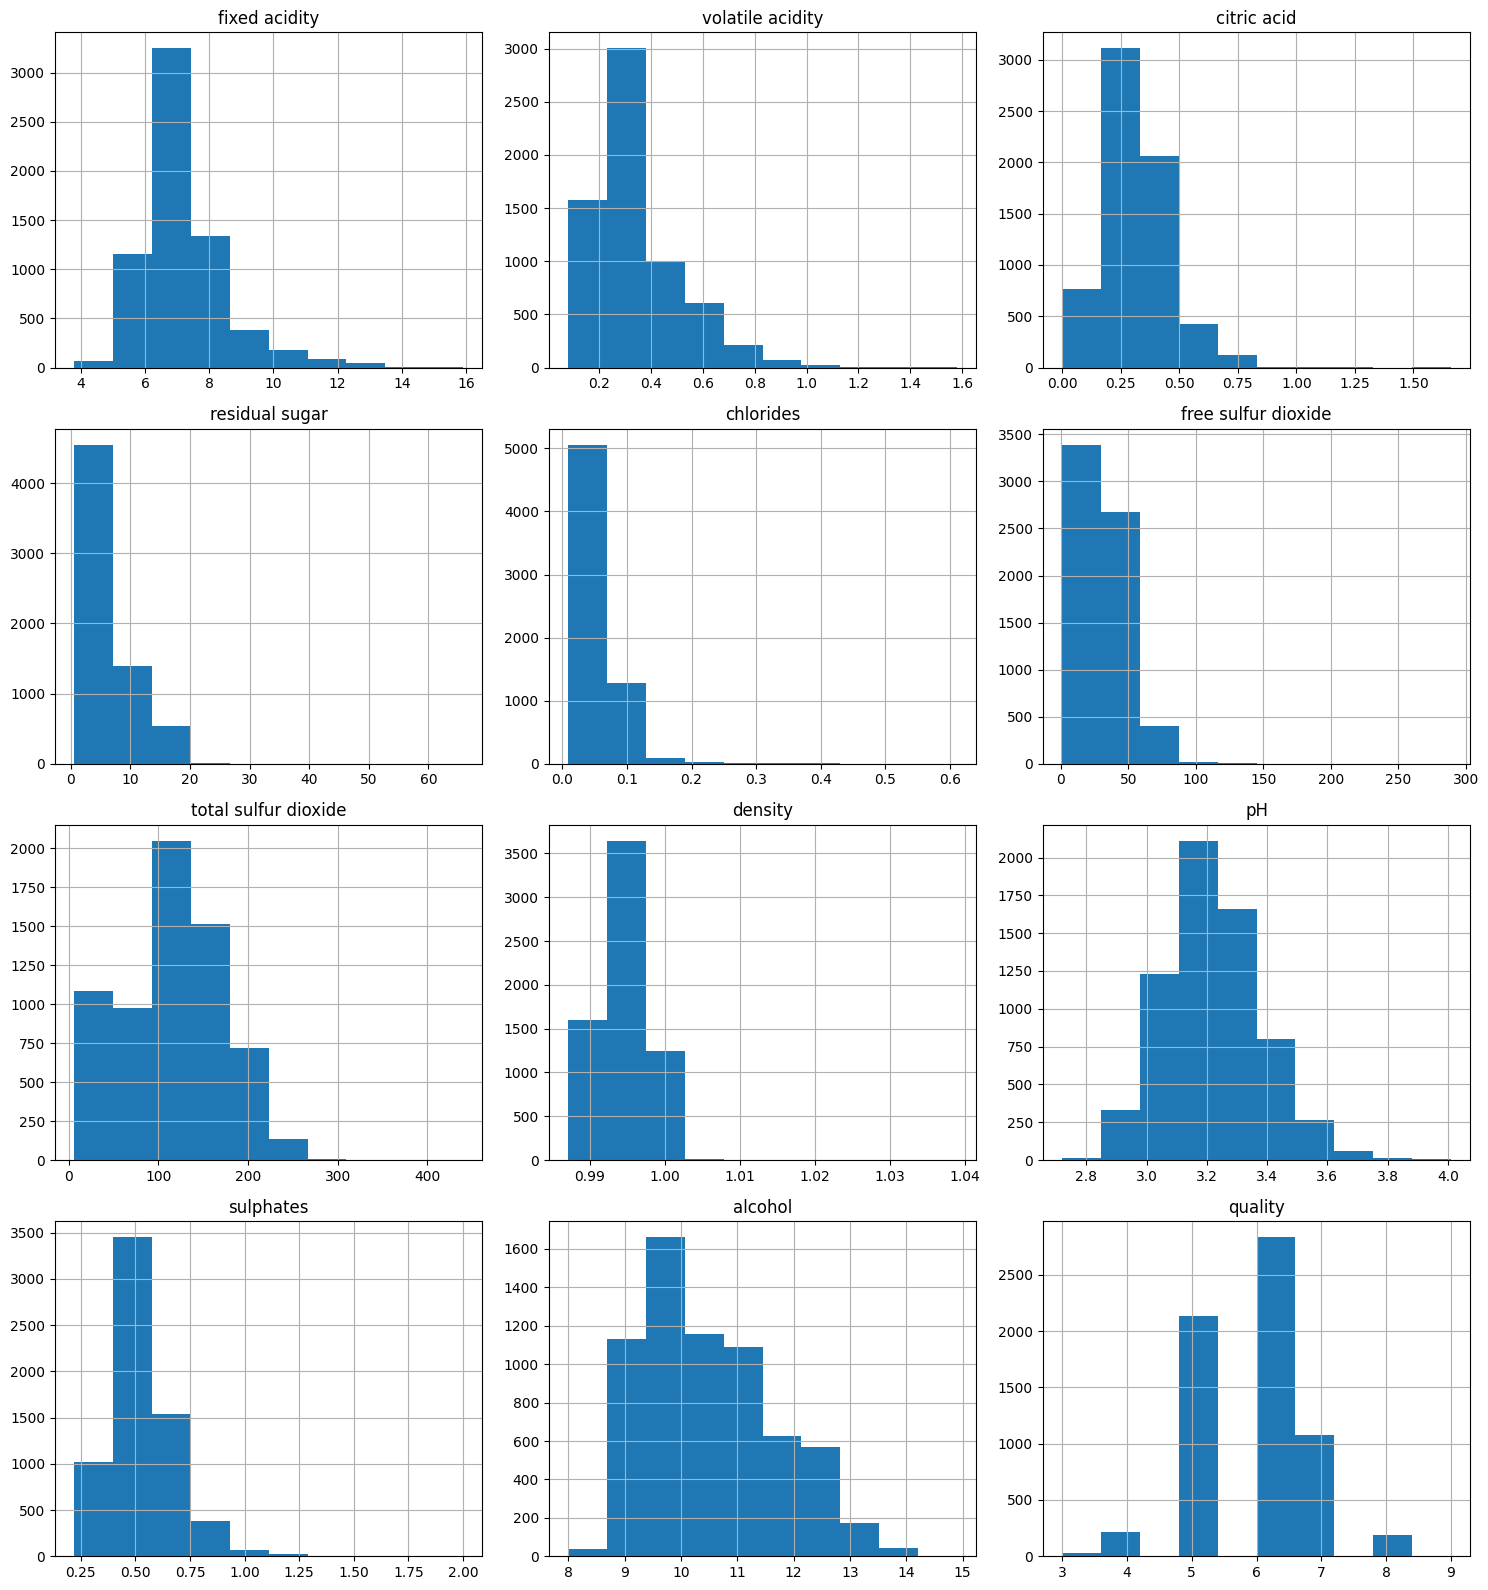

In [61]:
df[numeric_cols].hist(bins=10, figsize=(5*n_cols, 4*n_rows))
plt.tight_layout()

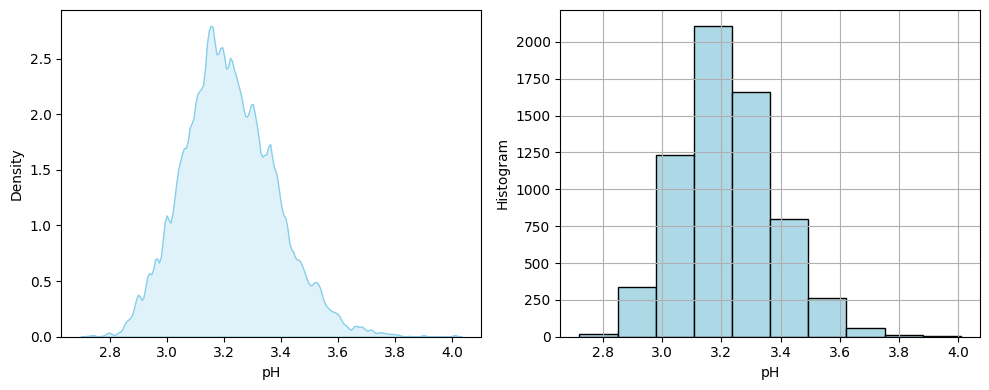

In [78]:
_, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

sns.kdeplot(df['pH'], fill=True, bw_adjust=0.3, color='skyblue', ax=axes[0])
df['pH'].hist(bins=10, color='lightblue', edgecolor='black', ax=axes[1])

axes[1].set_ylabel('Histogram')
axes[1].set_xlabel('pH')
plt.tight_layout()

<Axes: xlabel='pH', ylabel='Density'>

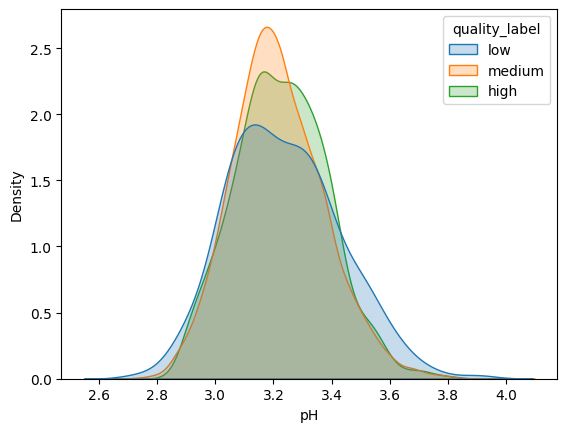

In [68]:
sns.kdeplot(data=df, x='pH', hue='quality_label', fill=True, common_norm=False)